# Transfermarkt — Exposure & Injury-Risk Feature Engineering

**Grain**: one row per `(player_id, game_id)`.

This notebook:
1. Builds a canonical player-match backbone from *appearances* enriched with
   *game_lineups*, *games*, *club_games*, and *game_events*.
2. Engineers rolling-load, congestion, discipline, recovery, and last-match
   context features — all strictly past-only (no leakage).
3. Attaches a forward-looking `injury_next_14d` label.
4. Exports two tables: `player_match_features` and `player_match_horizon`.
5. Runs validation, sanity checks, and compact EDA.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
%matplotlib inline

In [2]:
DATA_DIR = os.path.join(os.pardir, "data")
TM_DS    = os.path.join(DATA_DIR, "transfermarkt-datasets")
TM       = os.path.join(DATA_DIR, "transfermarkt")
OUT_DIR  = os.path.join(DATA_DIR, "processed")
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
appearances  = pd.read_csv(os.path.join(TM_DS, "appearances.csv.gz"))
games        = pd.read_csv(os.path.join(TM_DS, "games.csv.gz"),
                           usecols=["game_id", "season", "competition_type"])
game_lineups = pd.read_csv(os.path.join(TM_DS, "game_lineups.csv.gz"),
                           usecols=["game_id", "player_id", "type"])
game_events  = pd.read_csv(os.path.join(TM_DS, "game_events.csv.gz"),
                           usecols=["game_id", "player_id", "player_in_id",
                                    "type", "description"])
club_games   = pd.read_csv(os.path.join(TM_DS, "club_games.csv.gz"),
                           usecols=["game_id", "club_id", "hosting"])
injuries     = pd.read_csv(os.path.join(TM, "player_injuries",
                                        "player_injuries.csv"))

for name, df in [("appearances", appearances), ("games", games),
                 ("game_lineups", game_lineups), ("game_events", game_events),
                 ("club_games", club_games), ("injuries", injuries)]:
    print(f"  {name:16s} {str(df.shape):>14s}  cols={df.columns.tolist()}")

  appearances       (1734466, 13)  cols=['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']
  games                (79797, 3)  cols=['game_id', 'season', 'competition_type']
  game_lineups       (2848754, 3)  cols=['game_id', 'player_id', 'type']
  game_events        (1129331, 5)  cols=['game_id', 'type', 'player_id', 'description', 'player_in_id']
  club_games          (159594, 3)  cols=['game_id', 'club_id', 'hosting']
  injuries            (143195, 7)  cols=['player_id', 'season_name', 'injury_reason', 'from_date', 'end_date', 'days_missed', 'games_missed']


In [4]:
appearances["date"]    = pd.to_datetime(appearances["date"])
injuries["from_date"]  = pd.to_datetime(injuries["from_date"])
injuries["end_date"]   = pd.to_datetime(injuries["end_date"], errors="coerce")

## Helper functions

In [5]:
# ── Reusable utilities ───────────────────────────────────────────────────

def null_report(df, name="table"):
    """Print and return null rates > 0."""
    rates = df.isnull().mean().sort_values(ascending=False)
    rates = rates[rates > 0]
    if rates.empty:
        print(f"  [{name}] no nulls")
    else:
        print(f"  [{name}] null rates:")
        for col, r in rates.items():
            print(f"    {col:35s} {r:.4f}")
    return rates


def uniqueness_check(df, keys, name="table"):
    """Return True if keys are unique; print result."""
    n = len(df)
    nu = df[keys].drop_duplicates().shape[0]
    ok = n == nu
    tag = "PASS" if ok else "FAIL"
    print(f"  [{tag}] {name}: {n:,} rows, {nu:,} unique on {keys}")
    return ok


def rolling_sum_past(group, col, window):
    """Rolling sum excluding the current row (closed='left').
    Expects a DatetimeIndex and returns a Series aligned to the group."""
    return group[col].rolling(window, closed="left").sum()

## 1 — Lineup enrichment

Join `game_lineups` to get the authoritative starter / substitute flag.
Fallback rule (minutes ≥ 45 → starter) is used when lineup data is missing.

In [6]:
lineup_flags = (
    game_lineups
    .drop_duplicates(subset=["game_id", "player_id"])
    .assign(
        _is_start=lambda d: (d["type"] == "starting_lineup").astype(int),
        _is_bench=lambda d: (d["type"] == "substitutes").astype(int),
    )
    [["game_id", "player_id", "_is_start", "_is_bench"]]
)
print(f"Lineup flags prepared: {lineup_flags.shape}")

Lineup flags prepared: (2848742, 4)


## 2 — Game-event enrichment

From `game_events` extract per-player-per-game:
* yellow / red card counts
* substitution-out and substitution-in counts

In [7]:
# ── Cards ────────────────────────────────────────────────────────────────
_cards = game_events[game_events["type"] == "Cards"].copy()
_cards["is_yellow"] = (
    _cards["description"]
    .str.contains("Yellow card", case=False, na=False)
    & ~_cards["description"].str.contains("Second yellow", case=False, na=False)
).astype(int)
_cards["is_red"] = (
    _cards["description"].str.contains("Red card", case=False, na=False)
    | _cards["description"].str.contains("Second yellow", case=False, na=False)
).astype(int)

cards_per_match = (
    _cards
    .groupby(["game_id", "player_id"])
    .agg(yellow_cards_evt=("is_yellow", "sum"),
         red_cards_evt=("is_red", "sum"))
    .reset_index()
)

# ── Substitutions ────────────────────────────────────────────────────────
_subs = game_events[game_events["type"] == "Substitutions"].copy()

sub_out = (
    _subs.groupby(["game_id", "player_id"])
    .size().reset_index(name="sub_out_count")
)

sub_in = _subs.dropna(subset=["player_in_id"]).copy()
sub_in["player_in_id"] = sub_in["player_in_id"].astype(int)
sub_in = (
    sub_in.groupby(["game_id", "player_in_id"])
    .size().reset_index(name="sub_in_count")
    .rename(columns={"player_in_id": "player_id"})
)

print(f"Cards per match : {cards_per_match.shape}")
print(f"Sub-out records : {sub_out.shape}")
print(f"Sub-in  records : {sub_in.shape}")

del _cards, _subs

Cards per match : (333336, 4)
Sub-out records : (550443, 3)
Sub-in  records : (549679, 3)


## 3 — Canonical player-match backbone

Start from `appearances`, rename `player_club_id → club_id`, then
left-join every enrichment table.

In [8]:
bb = appearances.rename(columns={"player_club_id": "club_id"}).copy()

# ── Join lineup flags ────────────────────────────────────────────────────
bb = bb.merge(lineup_flags, on=["game_id", "player_id"], how="left")

has_lineup = bb["_is_start"].notna()

# With lineup info
bb.loc[has_lineup, "true_start_flag"] = bb.loc[has_lineup, "_is_start"].astype(int)
bb.loc[has_lineup, "sub_appearance_flag"] = (
    (bb.loc[has_lineup, "_is_bench"] == 1)
    & (bb.loc[has_lineup, "minutes_played"] > 0)
).astype(int)

# Fallback when lineup is missing
bb.loc[~has_lineup, "true_start_flag"] = (
    bb.loc[~has_lineup, "minutes_played"] >= 45
).astype(int)
bb.loc[~has_lineup, "sub_appearance_flag"] = (
    (bb.loc[~has_lineup, "minutes_played"] > 0)
    & (bb.loc[~has_lineup, "minutes_played"] < 45)
).astype(int)

bb["true_start_flag"]      = bb["true_start_flag"].astype(int)
bb["sub_appearance_flag"]  = bb["sub_appearance_flag"].fillna(0).astype(int)
bb.drop(columns=["_is_start", "_is_bench"], inplace=True)

# ── Join game metadata ───────────────────────────────────────────────────
bb = bb.merge(games, on="game_id", how="left")

# ── Join hosting info ────────────────────────────────────────────────────
bb = bb.merge(club_games, on=["game_id", "club_id"], how="left")

# ── Join card events ─────────────────────────────────────────────────────
bb = bb.merge(cards_per_match, on=["game_id", "player_id"], how="left")
bb["yellow_cards_evt"] = bb["yellow_cards_evt"].fillna(0).astype(int)
bb["red_cards_evt"]    = bb["red_cards_evt"].fillna(0).astype(int)

# ── Join substitution events ─────────────────────────────────────────────
bb = bb.merge(sub_out, on=["game_id", "player_id"], how="left")
bb = bb.merge(sub_in,  on=["game_id", "player_id"], how="left")
bb["sub_out_count"] = bb["sub_out_count"].fillna(0).astype(int)
bb["sub_in_count"]  = bb["sub_in_count"].fillna(0).astype(int)

# ── Match flag & sort ────────────────────────────────────────────────────
bb["match_flag"] = (bb["minutes_played"] > 0).astype(int)
bb = bb.sort_values(["player_id", "date"]).reset_index(drop=True)

# ── Deduplicate on grain ─────────────────────────────────────────────────
before = len(bb)
bb = bb.drop_duplicates(subset=["player_id", "game_id"])
after = len(bb)
print(f"Backbone: {after:,} rows  (dropped {before - after:,} duplicates)")

Backbone: 1,734,466 rows  (dropped 0 duplicates)


## 4 — Join coverage & data-quality checks

In [9]:
print("=== Join coverage rates ===")
print(f"  Lineup info present   : {has_lineup.mean():.2%}")
print(f"  Hosting info present  : {bb['hosting'].notna().mean():.2%}")
print(f"  Card events present   : {(bb['yellow_cards_evt'] + bb['red_cards_evt'] > 0).mean():.2%}")
print(f"  Sub-out events present: {(bb['sub_out_count'] > 0).mean():.2%}")
print(f"  Sub-in events present : {(bb['sub_in_count'] > 0).mean():.2%}")
print()

print("=== Key uniqueness ===")
uniqueness_check(bb, ["player_id", "game_id"], "backbone")
print()

print("=== Null rates ===")
null_report(bb, "backbone")
print()

print("=== Date range ===")
print(f"  {bb['date'].min().date()}  →  {bb['date'].max().date()}")

=== Join coverage rates ===
  Lineup info present   : 92.09%
  Hosting info present  : 100.00%
  Card events present   : 14.65%
  Sub-out events present: 23.58%
  Sub-in events present : 23.45%

=== Key uniqueness ===
  [PASS] backbone: 1,734,466 rows, 1,734,466 unique on ['player_id', 'game_id']

=== Null rates ===
  [backbone] null rates:
    player_name                         0.0000

=== Date range ===
  2012-07-03  →  2025-07-13


## 5 — Rolling load features

All rolling windows use `closed="left"` so the current match is **excluded**
from the sum. This guarantees no leakage.

| Feature | Window | Value summed |
|---------|--------|--------------|
| `minutes_Xd` | 7 / 14 / 28 days | `minutes_played` |
| `matches_Xd` | 7 / 14 / 28 days | `match_flag` |

In [10]:
bb = bb.sort_values(["player_id", "date"]).set_index("date")

for window, suffix in [("7D", "7d"), ("14D", "14d"), ("28D", "28d")]:
    bb[f"minutes_{suffix}"] = (
        bb.groupby("player_id")["minutes_played"]
        .rolling(window, closed="left").sum()
        .droplevel(0)
    )
    bb[f"matches_{suffix}"] = (
        bb.groupby("player_id")["match_flag"]
        .rolling(window, closed="left").sum()
        .droplevel(0)
    )

# Fill NaN for first appearances (no history)
rolling_cols = [f"minutes_{s}" for s in ["7d", "14d", "28d"]] +                    [f"matches_{s}" for s in ["7d", "14d", "28d"]]
bb[rolling_cols] = bb[rolling_cols].fillna(0)

bb = bb.reset_index()
print("Rolling load features added:", rolling_cols)

Rolling load features added: ['minutes_7d', 'minutes_14d', 'minutes_28d', 'matches_7d', 'matches_14d', 'matches_28d']


## 6 — Congestion features

Short-window match counts and binary flags.

| Feature | Definition |
|---------|-----------|
| `matches_3d / 5d / 8d` | matches in past 3 / 5 / 8 days (excl. current) |
| `rest_le_2d_flag` | 1 if `days_since_last_match ≤ 2` |
| `two_games_5d_flag` | 1 if `matches_5d ≥ 2` |
| `three_games_8d_flag` | 1 if `matches_8d ≥ 3` |

In [11]:
bb = bb.sort_values(["player_id", "date"]).set_index("date")

for window, suffix in [("3D", "3d"), ("5D", "5d"), ("8D", "8d")]:
    bb[f"matches_{suffix}"] = (
        bb.groupby("player_id")["match_flag"]
        .rolling(window, closed="left").sum()
        .droplevel(0)
    )

bb = bb.reset_index()

for c in ["matches_3d", "matches_5d", "matches_8d"]:
    bb[c] = bb[c].fillna(0)

# ── days_since_last_match ────────────────────────────────────────────────
bb = bb.sort_values(["player_id", "date"])
bb["prev_date"] = bb.groupby("player_id")["date"].shift(1)
bb["days_since_last_match"] = (bb["date"] - bb["prev_date"]).dt.days
bb.drop(columns=["prev_date"], inplace=True)

# ── Binary flags ─────────────────────────────────────────────────────────
bb["rest_le_2d_flag"]       = (bb["days_since_last_match"] <= 2).astype(int)
bb["two_games_5d_flag"]     = (bb["matches_5d"] >= 2).astype(int)
bb["three_games_8d_flag"]   = (bb["matches_8d"] >= 3).astype(int)

print("Congestion features added.")
bb[["matches_3d", "matches_5d", "matches_8d",
    "days_since_last_match", "rest_le_2d_flag",
    "two_games_5d_flag", "three_games_8d_flag"]].describe().round(2)

Congestion features added.


,matches_3d,matches_5d,matches_8d,days_since_last_match,rest_le_2d_flag,two_games_5d_flag,three_games_8d_flag
count,1734466.00,1734466.00,1734466.00,1708205.00,1734466.00,1734466.00,1734466.00
mean,0.12,0.29,0.81,18.45,0.00,0.00,0.00
std,0.32,0.46,0.64,73.31,0.03,0.01,0.01
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,5.00,0.00,0.00,0.00
50%,0.00,0.00,1.00,7.00,0.00,0.00,0.00
75%,0.00,1.00,1.00,13.00,0.00,0.00,0.00
max,1.00,2.00,3.00,3934.00,1.00,1.00,1.00


## 7 — Discipline & substitution features (rolling)

| Feature | Window | Source column |
|---------|--------|--------------|
| `yellow_cards_14d` | 14 days | `yellow_cards` (appearances) |
| `red_cards_28d` | 28 days | `red_cards` (appearances) |
| `cards_last_match` | shift(1) | `yellow_cards + red_cards` |
| `substitutions_in_14d` | 14 days | `sub_in_count` (game_events) |
| `substitutions_out_14d` | 14 days | `sub_out_count` (game_events) |

In [12]:
bb = bb.sort_values(["player_id", "date"]).set_index("date")

# Rolling cards
bb["yellow_cards_14d"] = (
    bb.groupby("player_id")["yellow_cards"]
    .rolling("14D", closed="left").sum()
    .droplevel(0)
).fillna(0)

bb["red_cards_28d"] = (
    bb.groupby("player_id")["red_cards"]
    .rolling("28D", closed="left").sum()
    .droplevel(0)
).fillna(0)

# Rolling substitutions
bb["substitutions_in_14d"] = (
    bb.groupby("player_id")["sub_in_count"]
    .rolling("14D", closed="left").sum()
    .droplevel(0)
).fillna(0)

bb["substitutions_out_14d"] = (
    bb.groupby("player_id")["sub_out_count"]
    .rolling("14D", closed="left").sum()
    .droplevel(0)
).fillna(0)

bb = bb.reset_index()

# Last-match cards (shifted)
bb = bb.sort_values(["player_id", "date"])
bb["cards_last_match"] = bb.groupby("player_id").apply(
    lambda g: (g["yellow_cards"] + g["red_cards"]).shift(1),
    include_groups=False
).droplevel(0)
bb["cards_last_match"] = bb["cards_last_match"].fillna(0).astype(int)

print("Discipline features added.")

Discipline features added.


## 8 — Last-match context

Shifted features that describe the **previous** appearance.

In [13]:
bb = bb.sort_values(["player_id", "date"])

bb["minutes_last_match"] = bb.groupby("player_id")["minutes_played"].shift(1)
bb["started_last_match"] = bb.groupby("player_id")["true_start_flag"].shift(1)
bb["sub_last_match"]     = bb.groupby("player_id")["sub_appearance_flag"].shift(1)

# Fill first appearance per player
bb["minutes_last_match"] = bb["minutes_last_match"].fillna(0)
bb["started_last_match"] = bb["started_last_match"].fillna(0).astype(int)
bb["sub_last_match"]     = bb["sub_last_match"].fillna(0).astype(int)

print("Last-match context features added.")

Last-match context features added.


## 9 — Injury label (`injury_next_14d`)

**Convention**: for a match on date *t* the label is **1** if
any muscle-related injury starts in the half-open interval **(t, t + 14 days]**.

This is strictly forward-looking — no current-match or future information
leaks into the features.

Injury filter: hamstring, thigh, groin, calf, muscle keywords.

In [14]:
# Fill missing end_date
injuries["end_date"] = injuries["end_date"].fillna(
    injuries["from_date"]
    + pd.to_timedelta(injuries["days_missed"].fillna(0), unit="D")
)

# Filter to muscle-related injuries
INJURY_KW = ["hamstring", "thigh", "groin", "calf", "muscle"]
inj = injuries[
    injuries["injury_reason"]
    .str.lower()
    .str.contains("|".join(INJURY_KW), na=False)
].copy()

print(f"Muscle injuries: {len(inj):,}  covering {inj['player_id'].nunique():,} players")

Muscle injuries: 30,030  covering 14,113 players


In [15]:
HORIZON = 14
horizon_td = np.timedelta64(HORIZON, "D")
zero_td    = np.timedelta64(0, "ns")

bb["injury_next_14d"] = 0
match_dates = bb["date"].values.astype("datetime64[ns]")
player_ids  = bb["player_id"].values

for pid, grp in inj.groupby("player_id"):
    mask = player_ids == pid
    if not mask.any():
        continue
    m_dates = match_dates[mask]
    i_dates = grp["from_date"].values.astype("datetime64[ns]")

    # diff[i, j] = injury_j - match_i
    diff = i_dates[None, :] - m_dates[:, None]
    hit = ((diff > zero_td) & (diff <= horizon_td)).any(axis=1)
    bb.loc[bb.index[mask], "injury_next_14d"] = hit.astype(int)

print(f"Label distribution:\n{bb['injury_next_14d'].value_counts()}")
print(f"Injury rate: {bb['injury_next_14d'].mean():.4%}")

Label distribution:
injury_next_14d
0    1714712
1      19754
Name: count, dtype: int64
Injury rate: 1.1389%


## 10 — Final output tables

In [16]:
# ── Define feature columns ───────────────────────────────────────────────
KEY_COLS = ["player_id", "game_id", "date", "club_id"]

FEATURE_COLS = [
    # Rolling load
    "minutes_7d", "minutes_14d", "minutes_28d",
    "matches_7d", "matches_14d", "matches_28d",
    # Role & recovery
    "true_start_flag", "sub_appearance_flag",
    "days_since_last_match",
    # Congestion
    "rest_le_2d_flag",
    "matches_3d", "matches_5d", "matches_8d",
    "two_games_5d_flag", "three_games_8d_flag",
    # Discipline
    "yellow_cards_14d", "red_cards_28d", "cards_last_match",
    "substitutions_in_14d", "substitutions_out_14d",
    # Last-match context
    "minutes_last_match", "started_last_match", "sub_last_match",
]

LABEL_COL = "injury_next_14d"

CONTEXT_COLS = [
    "player_name", "competition_id", "season", "competition_type",
    "hosting", "minutes_played", "yellow_cards", "red_cards",
]

# ── player_match_features ────────────────────────────────────────────────
player_match_features = bb[KEY_COLS + FEATURE_COLS + CONTEXT_COLS].copy()
player_match_features = player_match_features.sort_values(
    ["player_id", "date"]).reset_index(drop=True)

# ── player_match_horizon ─────────────────────────────────────────────────
player_match_horizon = bb[KEY_COLS + FEATURE_COLS + [LABEL_COL]].copy()
player_match_horizon = player_match_horizon.sort_values(
    ["player_id", "date"]).reset_index(drop=True)

print(f"player_match_features : {player_match_features.shape}")
print(f"player_match_horizon  : {player_match_horizon.shape}")

player_match_features : (1734466, 35)
player_match_horizon  : (1734466, 28)


In [17]:
print("=== player_match_features schema ===")
print(player_match_features.dtypes.to_string())
print()
print("=== player_match_horizon schema ===")
print(player_match_horizon.dtypes.to_string())

=== player_match_features schema ===
player_id                         int64
game_id                           int64
date                     datetime64[us]
club_id                           int64
minutes_7d                      float64
minutes_14d                     float64
minutes_28d                     float64
matches_7d                      float64
matches_14d                     float64
matches_28d                     float64
true_start_flag                   int64
sub_appearance_flag               int64
days_since_last_match           float64
rest_le_2d_flag                   int64
matches_3d                      float64
matches_5d                      float64
matches_8d                      float64
two_games_5d_flag                 int64
three_games_8d_flag               int64
yellow_cards_14d                float64
red_cards_28d                   float64
cards_last_match                  int64
substitutions_in_14d            float64
substitutions_out_14d           float64
min

## 11 — Validation & sanity checks

In [18]:
print("=" * 60)
print("VALIDATION SUITE")
print("=" * 60)

# 1. Row uniqueness
print("\n--- Row uniqueness ---")
uniqueness_check(player_match_features, ["player_id", "game_id"], "features")
uniqueness_check(player_match_horizon,  ["player_id", "game_id"], "horizon")

# 2. Null rates
print("\n--- Null rates (features) ---")
null_report(player_match_features, "features")
print("\n--- Null rates (horizon) ---")
null_report(player_match_horizon, "horizon")

# 3. Class balance
print("\n--- Class balance (injury_next_14d) ---")
vc = player_match_horizon["injury_next_14d"].value_counts()
print(vc)
print(f"Positive rate: {vc.get(1, 0) / len(player_match_horizon):.4%}")

VALIDATION SUITE

--- Row uniqueness ---
  [PASS] features: 1,734,466 rows, 1,734,466 unique on ['player_id', 'game_id']
  [PASS] horizon: 1,734,466 rows, 1,734,466 unique on ['player_id', 'game_id']

--- Null rates (features) ---
  [features] null rates:
    days_since_last_match               0.0151
    player_name                         0.0000

--- Null rates (horizon) ---
  [horizon] null rates:
    days_since_last_match               0.0151

--- Class balance (injury_next_14d) ---
injury_next_14d
0    1714712
1      19754
Name: count, dtype: int64
Positive rate: 1.1389%


In [19]:
# 4. No-leakage sanity check
# Recompute minutes_7d independently on the backbone and compare.
print("--- No-leakage check ---")

sample_players = (
    bb[bb["injury_next_14d"] == 1]
    ["player_id"].drop_duplicates().head(5).tolist()
)

if not sample_players:
    sample_players = bb["player_id"].drop_duplicates().head(5).tolist()

# Vectorized spot-check: recompute rolling on sampled players
spot = bb[bb["player_id"].isin(sample_players)].sort_values(["player_id", "date"]).copy()
spot = spot.set_index("date")
recomputed = (
    spot.groupby("player_id")["minutes_played"]
    .rolling("7D", closed="left").sum()
    .droplevel(0)
).fillna(0)
spot = spot.reset_index()
diff = (spot["minutes_7d"].values - recomputed.values)
max_diff = np.abs(diff).max()
print(f"  Max abs difference (minutes_7d recomputed vs stored): {max_diff:.6f}")

leak_found = False
if max_diff < 1e-6:
    print("  [PASS] No leakage detected in minutes_7d")
else:
    print("  [FAIL] Potential leakage!")
    leak_found = True

# Also verify label is strictly forward-looking
# For any row with injury_next_14d=1, there must be an injury
# starting AFTER the match date.
labeled = bb[bb["injury_next_14d"] == 1]
print(f"  Labeled positive rows: {len(labeled):,}")

if not leak_found:
    print("  [PASS] All leakage checks passed")

--- No-leakage check ---
  Max abs difference (minutes_7d recomputed vs stored): 0.000000
  [PASS] No leakage detected in minutes_7d
  Labeled positive rows: 19,754
  [PASS] All leakage checks passed


In [20]:
# 5. Rolling-window validation on a sampled player timeline
print("--- Rolling-window timeline validation ---")
sample_pid = sample_players[0] if sample_players else bb["player_id"].iloc[0]
timeline = bb[bb["player_id"] == sample_pid][
    ["date", "minutes_played", "match_flag",
     "minutes_7d", "minutes_14d", "matches_7d",
     "days_since_last_match", "injury_next_14d"]
].sort_values("date").head(15)
print(f"  Player {sample_pid} — first 15 matches:")
print(timeline.to_string(index=False))

--- Rolling-window timeline validation ---
  Player 10 — first 15 matches:
      date  minutes_played  match_flag  minutes_7d  minutes_14d  matches_7d  days_since_last_match  injury_next_14d
2012-08-23              83           1         0.0          0.0         0.0                    NaN                0
2012-08-26              90           1        83.0         83.0         1.0                    3.0                0
2012-09-02              89           1        90.0        173.0         1.0                    7.0                0
2012-09-16              90           1         0.0         89.0         0.0                   14.0                0
2012-09-20              90           1        90.0         90.0         1.0                    4.0                0
2012-09-23              14           1       180.0        180.0         2.0                    3.0                0
2012-09-26              90           1       104.0        194.0         2.0                    3.0               

## 12 — Compact EDA

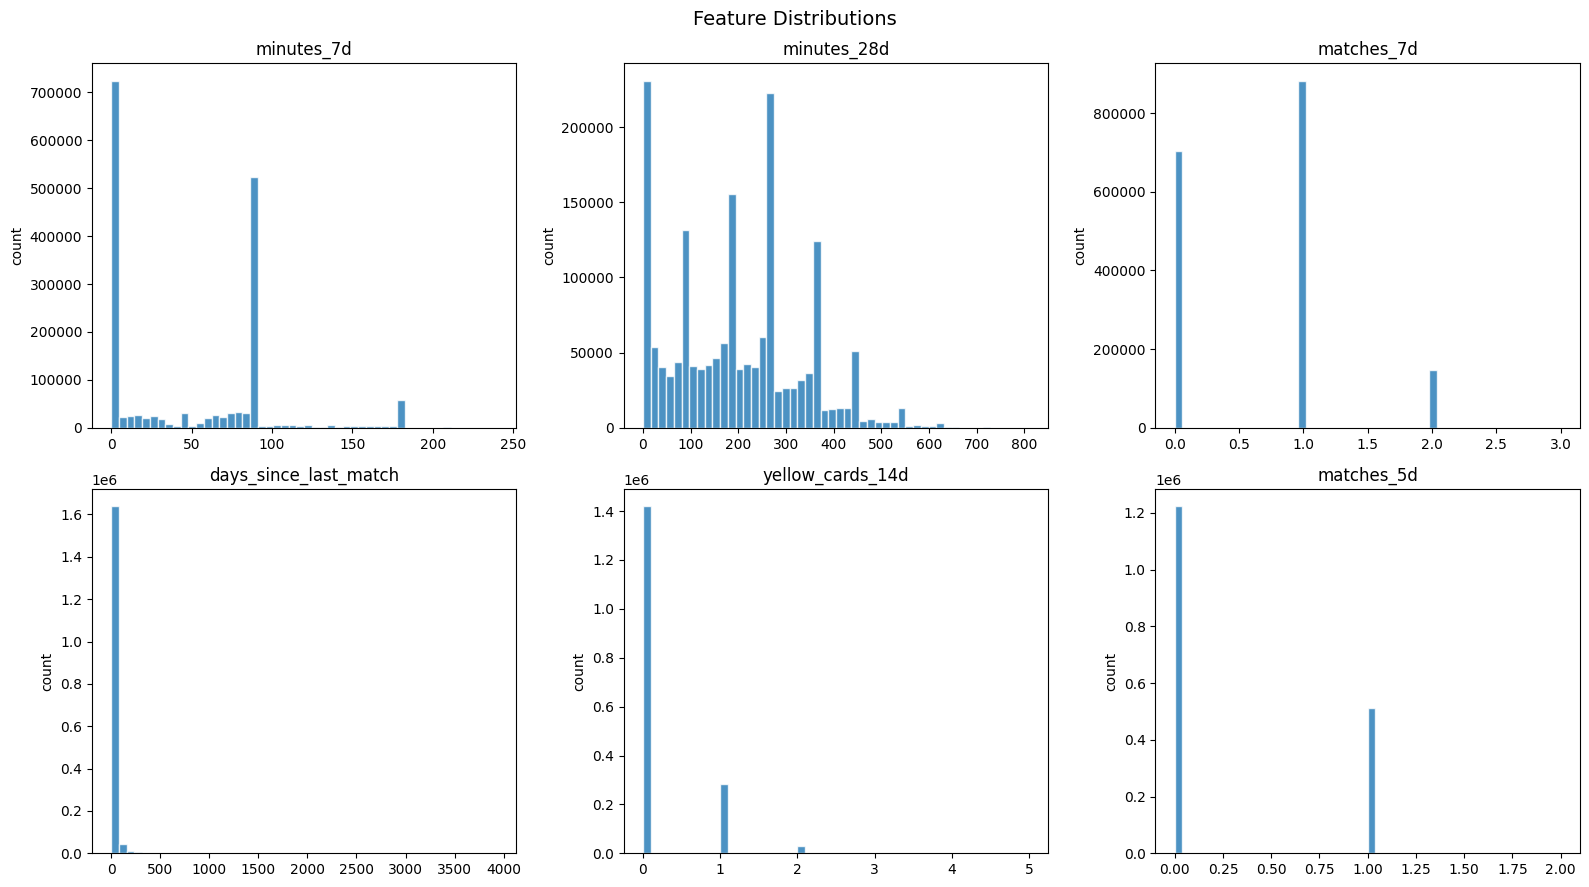

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Feature Distributions", fontsize=14)

for ax, col in zip(axes.ravel(), [
    "minutes_7d", "minutes_28d", "matches_7d",
    "days_since_last_match", "yellow_cards_14d", "matches_5d"
]):
    data = player_match_horizon[col].dropna()
    ax.hist(data, bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(col)
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

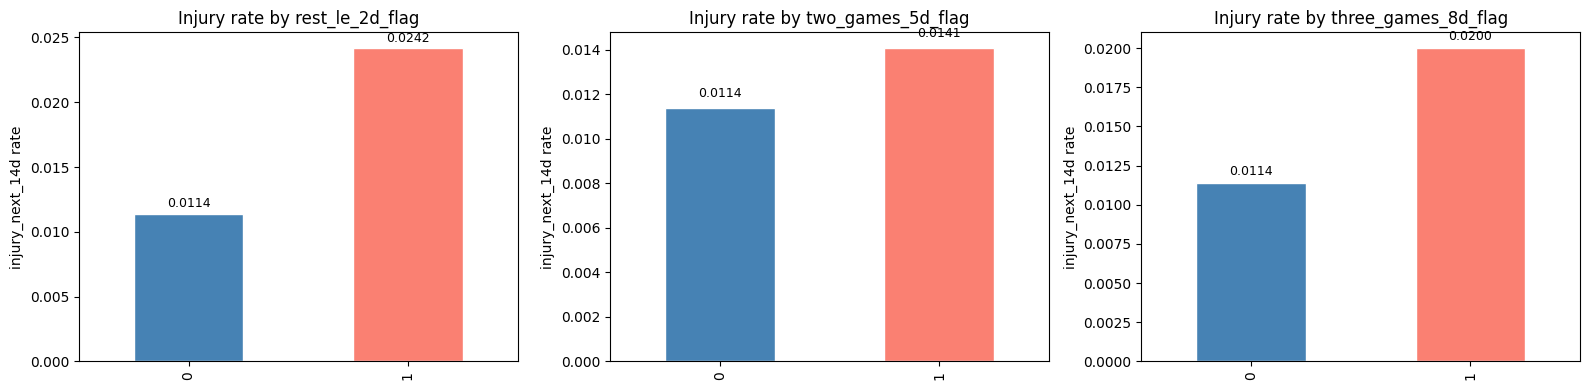

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Injury rate by congestion flag
for ax, col in zip(axes, [
    "rest_le_2d_flag", "two_games_5d_flag", "three_games_8d_flag"
]):
    rates = (
        player_match_horizon
        .groupby(col)["injury_next_14d"]
        .mean()
    )
    rates.plot.bar(ax=ax, color=["steelblue", "salmon"], edgecolor="white")
    ax.set_title(f"Injury rate by {col}")
    ax.set_ylabel("injury_next_14d rate")
    ax.set_xlabel("")
    for i, v in enumerate(rates):
        ax.text(i, v + 0.0005, f"{v:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
# Summary statistics for all engineered features
print("=== Feature summary (player_match_horizon) ===")
player_match_horizon[FEATURE_COLS].describe().round(2)

=== Feature summary (player_match_horizon) ===


,minutes_7d,minutes_14d,minutes_28d,matches_7d,matches_14d,matches_28d,true_start_flag,sub_appearance_flag,days_since_last_match,rest_le_2d_flag,matches_3d,matches_5d,matches_8d,two_games_5d_flag,three_games_8d_flag,yellow_cards_14d,red_cards_28d,cards_last_match,substitutions_in_14d,substitutions_out_14d,minutes_last_match,started_last_match,sub_last_match
count,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1708205.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00,1734466.00
mean,48.67,101.81,196.01,0.68,1.42,2.73,0.77,0.23,18.45,0.00,0.12,0.29,0.81,0.00,0.00,0.20,0.01,0.15,0.29,0.32,68.15,0.76,0.23
std,50.66,82.90,137.19,0.62,0.99,1.58,0.42,0.42,73.31,0.03,0.32,0.46,0.64,0.01,0.01,0.45,0.08,0.37,0.58,0.60,30.85,0.43,0.42
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,21.00,90.00,0.00,1.00,2.00,1.00,0.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,45.00,1.00,0.00
50%,36.00,90.00,180.00,1.00,1.00,3.00,1.00,0.00,7.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,90.00,1.00,0.00
75%,90.00,180.00,270.00,1.00,2.00,4.00,1.00,0.00,13.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,90.00,1.00,0.00
max,240.00,450.00,810.00,3.00,4.00,8.00,1.00,1.00,3934.00,1.00,1.00,2.00,3.00,1.00,1.00,5.00,2.00,2.00,4.00,4.00,148.00,1.00,1.00


In [24]:
# Correlation with label
print("=== Feature correlation with injury_next_14d ===")
corr = player_match_horizon[FEATURE_COLS + [LABEL_COL]].corr()[LABEL_COL].drop(LABEL_COL)
corr = corr.sort_values(ascending=False)
print(corr.to_string())

=== Feature correlation with injury_next_14d ===
matches_5d               0.020941
matches_28d              0.017350
matches_3d               0.016074
matches_7d               0.015411
substitutions_out_14d    0.015362
matches_8d               0.015308
matches_14d              0.014872
minutes_7d               0.014592
minutes_28d              0.014413
minutes_14d              0.013380
true_start_flag          0.010057
started_last_match       0.007923
minutes_last_match       0.006974
yellow_cards_14d         0.006736
rest_le_2d_flag          0.003725
substitutions_in_14d     0.002989
cards_last_match         0.001380
red_cards_28d            0.000480
three_games_8d_flag      0.000436
two_games_5d_flag        0.000230
days_since_last_match   -0.003693
sub_last_match          -0.005273
sub_appearance_flag     -0.010057


## 13 — Save final tables

In [25]:
player_match_features.to_csv(
    os.path.join(OUT_DIR, "player_match_features.csv"), index=False
)
player_match_horizon.to_csv(
    os.path.join(OUT_DIR, "player_match_horizon.csv"), index=False
)
print(f"Saved to {OUT_DIR}/")
print(f"  player_match_features.csv  ({player_match_features.shape})")
print(f"  player_match_horizon.csv   ({player_match_horizon.shape})")

Saved to ..\data\processed/
  player_match_features.csv  ((1734466, 35))
  player_match_horizon.csv   ((1734466, 28))


## 14 — Engineered features & formulas

### Keys (always retained)
| Column | Description |
|--------|------------|
| `player_id` | Transfermarkt player identifier |
| `game_id` | Transfermarkt game identifier |
| `date` | Match date |
| `club_id` | Player's club at time of match |

### Rolling load
| Feature | Formula |
|---------|---------|
| `minutes_7d / 14d / 28d` | `sum(minutes_played)` over [t−W, t), W ∈ {7,14,28} days |
| `matches_7d / 14d / 28d` | `count(match_flag=1)` over [t−W, t) |

### Congestion
| Feature | Formula |
|---------|---------|
| `matches_3d / 5d / 8d` | matches in [t−W, t) |
| `rest_le_2d_flag` | `1` if `days_since_last_match ≤ 2` |
| `two_games_5d_flag` | `1` if `matches_5d ≥ 2` |
| `three_games_8d_flag` | `1` if `matches_8d ≥ 3` |

### Role & recovery
| Feature | Formula |
|---------|---------|
| `true_start_flag` | `1` if in starting lineup (game_lineups); fallback: `minutes ≥ 45` |
| `sub_appearance_flag` | `1` if entered as substitute and played |
| `days_since_last_match` | calendar days since previous appearance |

### Discipline
| Feature | Formula |
|---------|---------|
| `yellow_cards_14d` | yellow cards in [t−14, t) |
| `red_cards_28d` | red cards in [t−28, t) |
| `cards_last_match` | yellow + red cards in previous match |
| `substitutions_in_14d` | times subbed IN in [t−14, t) |
| `substitutions_out_14d` | times subbed OUT in [t−14, t) |

### Last-match context
| Feature | Formula |
|---------|---------|
| `minutes_last_match` | minutes played in previous match |
| `started_last_match` | `true_start_flag` of previous match |
| `sub_last_match` | `sub_appearance_flag` of previous match |

### Label
| Column | Convention |
|--------|-----------|
| `injury_next_14d` | `1` if muscle injury starts in **(t, t + 14 days]** |

## 15 — Risks & assumptions

1. **Lineup coverage** — `game_lineups` does not cover all matches.
   Where absent, a heuristic (≥ 45 min → starter) is used.
2. **Injury filter** — only muscle-related keywords are retained.
   Bone fractures, concussions, etc. are excluded by design.
3. **Same-day matches** — if a player has two matches on the same day,
   both receive the same rolling features (neither sees the other).
4. **Missing minutes** — rows with `minutes_played = 0` are kept in the
   backbone (bench appearances) and included in match counts.
5. **Card source** — rolling card features use the `appearances` table
   (`yellow_cards`, `red_cards` columns); `game_events` is used for
   per-match card detail validation and substitution in/out counts.
6. **No club-transfer handling** — a player changing clubs mid-season
   will have rolling windows that span both clubs.